*Using Claude Code? Open it and paste this prompt:*

```
Clone https://github.com/SamDower/bluedot-tais-puzzle, cd into it, install dependencies with `pip install sentence-transformers torch`, and read the README to understand the puzzle. Then stop and wait for me — I want to drive the investigation myself, so don't run any analyses or propose which feature might be non-linear.
```

# BlueDot Technical AI Safety Puzzle #1

We trained a small classifier on short text inputs to predict eight binary features simultaneously, at over 95% accuracy on each:

- `number` — contains a digit or written-out number (3, seven, …)
- `question` — phrased as a question (ends in ?, or starts with who/what/why/…)
- `color` — contains a color word (red, blue, …)
- `food` — mentions food (pizza, apple, soup, …)
- `sentiment` — has positive vs. negative sentiment
- `country` — contains a country name (Japan, France, USA, …)
- `person` — contains a person's name (Alice, Mark, …)
- `body_part` — contains a body-part word (hand, eye, …)

After a particular layer L of this model, seven of these features are represented linearly, where a single direction in the activation space describes that feature. However, one feature is represented in a different way. Your job is to figure out which feature it is and how it is represented.

## The model architecture

The model consists of the `sentence-transformers/all-MiniLM-L6-v2` text encoder followed by a mean pool to get a single 384-dimensional representation of that input. This is then fed through a 5 layer MLP with ReLUs between the layers. The resulting 8 logits are then fed through individual sigmoid functions to recover the predicted probabilities for the 8 features.

![Model architecture](https://raw.githubusercontent.com/SamDower/bluedot-tais-puzzle/main/model_architecture.png)

The 8 probabilities don't need to sum to 1 because the eight features aren't mutually exclusive. The model was trained with per-feature binary cross-entropy across the eight outputs.

## What's in this repo

- `model.pt` — trained classifier state dict.
- `data/train.jsonl` — 7000 lines of `{"text": "...", "labels": [1, 1, 0, 0, 1, 0, 0, 1]}`. Labels indexed by `feature_names.json`.
- `data/test.jsonl` — 1500 lines, same format. Use this as a held-out test set.
- `feature_names.json` — the eight feature names, indexed 0–7.

## Setup (run this first)

Downloads the model and data. First run takes ~30s for the encoder download; re-runs are instant.

In [4]:
!pip install -q sentence-transformers torch
![ -d /content/bluedot-tais-puzzle ] || git clone https://github.com/SamDower/bluedot-tais-puzzle.git /content/bluedot-tais-puzzle
%cd /content/bluedot-tais-puzzle

/content/bluedot-tais-puzzle


## Task 1: Find the non-linear feature.

Identify which of the eight features is not represented linearly at the specified layer activations.

### Code to get you started

In [2]:
import torch, torch.nn as nn
from sentence_transformers import SentenceTransformer

# --- 1. Define the MLP head  ---
class Head(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 64), nn.ReLU(),   # hidden 0
            nn.Linear(64, 64),  nn.ReLU(),   # hidden 1
            nn.Linear(64, 64),  nn.ReLU(),   # hidden 2  ← non-linear activation here (post-ReLU)
            nn.Linear(64, 64),  nn.ReLU(),   # hidden 3
            nn.Linear(64, 8),                # logits
        )
    def forward(self, x):
        return self.layers(x)

# --- 2. Load encoder (downloaded from HF) and head (local file) ---
enc = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
m = Head()
m.load_state_dict(torch.load("model.pt", map_location="cpu", weights_only=False))
m.eval()

# --- 3. Get predictions ---
texts = [
    "Alice loves the red car she bought in Japan for two hundred dollars.",
    "Did Sarah eat pizza with her hands in Italy?",
]

with torch.no_grad():
    embeddings = torch.from_numpy(
        enc.encode(texts, convert_to_numpy=True)   # (N, 384), mean-pooled
    )
    logits = m(embeddings)                          # (N, 8)
    probs  = torch.sigmoid(logits)                  # (N, 8) — independent per feature
    preds  = (probs > 0.5).int()                    # (N, 8) — binary predictions

# --- 4. Get activations at the right spot (post-ReLU of hidden 2) ---
# layers[0:6] = Linear, ReLU, Linear, ReLU, Linear, ReLU  → output is hidden 2 post-ReLU
with torch.no_grad():
    layer2_acts = m.layers[:6](embeddings)          # (N, 64)

# --- 5. Show what we got ---
import json
feature_names = json.load(open("feature_names.json"))

print("\n\n")

for text, p in zip(texts, preds):
    active = [name for name, v in zip(feature_names, p.tolist()) if v == 1]
    print(f"  {text}")
    print(f"    -> {active}")

print(f"\nlayer 2 activations: {tuple(layer2_acts.shape)}")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]




  Alice loves the red car she bought in Japan for two hundred dollars.
    -> ['number', 'color', 'sentiment', 'country', 'person']
  Did Sarah eat pizza with her hands in Italy?
    -> ['question', 'food', 'sentiment', 'country', 'person', 'body_part']

layer 2 activations: (2, 64)


In [29]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
print(os.listdir('/content/bluedot-tais-puzzle'))
print(os.listdir('/content/bluedot-tais-puzzle/data/'))
df = pd.read_json('/content/bluedot-tais-puzzle/data/train.jsonl', lines=True)
X = df['text'].tolist()
Xembeddings = torch.from_numpy(
    enc.encode(X, convert_to_numpy=True)
)



ch_feat = 0
y = np.array(df['labels'].tolist())[:, ch_feat]


logica = LogisticRegression()
Xtrain, Xval, ytrain, yval = train_test_split(Xembeddings, y, test_size=0.2, random_state=42)
PREm = m.layers[:6]
logica.fit(PREm(Xtrain).detach().numpy(), ytrain)
print(accuracy_score(yval, logica.predict(PREm(Xval).detach().numpy()) ) )


['model_architecture.png', 'data', '.git', 'puzzle.ipynb', 'README.md', 'model.pt', 'feature_names.json']
['train.jsonl', 'test.jsonl']
1.0


In [33]:
mn = 0.6
mni = -1
for ch_feat in range(8):
    y = np.array(df['labels'].tolist())[:, ch_feat]
    
    
    logica = LogisticRegression()
    Xtrain, Xval, ytrain, yval = train_test_split(Xembeddings, y, test_size=0.2, random_state=42)
    PREm = m.layers[:6]
    logica.fit(PREm(Xtrain).detach().numpy(), ytrain)
    if accuracy_score(yval, logica.predict(PREm(Xval).detach().numpy()) ) < mn:
        mn = accuracy_score(yval, logica.predict(PREm(Xval).detach().numpy()) )
        mni = ch_feat
    print(ch_feat, accuracy_score(yval, logica.predict(PREm(Xval).detach().numpy()) ) )
print("hard to train feature", mni)

0 1.0
1 1.0
2 1.0
3 1.0
4 1.0
5 0.4642857142857143
6 1.0
7 1.0
hard to train feature 5


## Task 2: Explain how that feature is represented

Describe the geometric structure the model uses to represent this feature. Show the analysis you used to convince yourself.

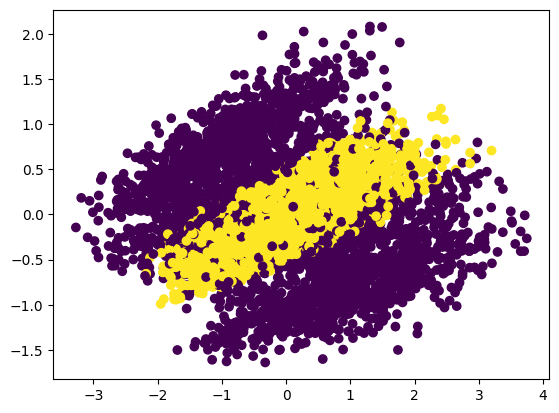

In [40]:
y = np.array(df['labels'].tolist())[:, mni]
logica = LogisticRegression()
Xtrain, Xval, ytrain, yval = train_test_split(PREm(Xembeddings).detach().numpy(), y, test_size=0.2, random_state=42)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
pc = PCA(2)
X2train = pc.fit_transform(Xtrain)
plt.scatter(X2train[:, 0], X2train[:, 1], c = ytrain)

In [43]:
from sklearn.neighbors import KNeighborsClassifier
y = np.array(df['labels'].tolist())[:, mni]
logica = KNeighborsClassifier(5)
Xtrain, Xval, ytrain, yval = train_test_split(Xembeddings, y, test_size=0.2, random_state=42)
PREm = m.layers[:6]
logica.fit(PREm(Xtrain).detach().numpy(), ytrain)w
if accuracy_score(yval, logica.predict(PREm(Xval).detach().numpy()) ) < mn:
    mn = accuracy_score(yval, logica.predict(PREm(Xval).detach().numpy()) )
    mni = ch_feat
print(ch_feat, accuracy_score(yval, logica.predict(PREm(Xval).detach().numpy()) ) )

7 0.9921428571428571


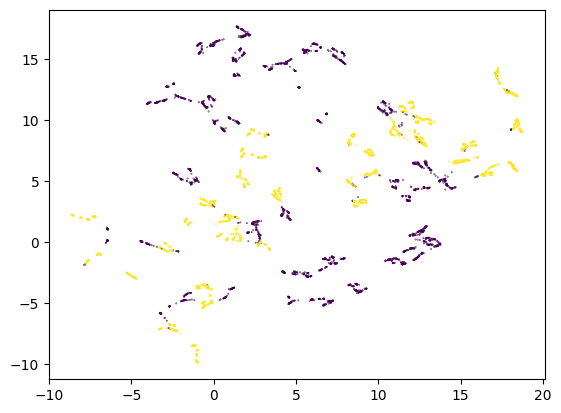

In [47]:
import umap
um = umap.UMAP(n_components = 2)
y = np.array(df['labels'].tolist())[:, mni]
Xtrain, Xval, ytrain, yval = train_test_split(PREm(Xembeddings).detach().numpy(), y, test_size=0.2, random_state=42)
X2train = um.fit_transform(Xtrain)
plt.scatter(X2train[:, 0], X2train[:, 1], c = ytrain, s = 0.1)

## Task 3: Train a model with an even weirder representation

*Open ended.* Train your own model that encodes that feature (or some other feature) in a more interesting way than ours. "More interesting" is up to you to define and defend.

In [49]:
feature_names = json.load(open("feature_names.json"))
feature_names

['number',
 'question',
 'color',
 'food',
 'sentiment',
 'country',
 'person',
 'body_part']

0.5071428571428571


,text,labels,template_id,is_question,The_Article
0,The driver eats those sad oatmeal dressed in brown in Netherlands.,"[0, 0, 1, 1, 0, 1, 0, 0]",7,1,1
1,"Kevin visits Ecuador, calling it harsh and bought a few songs wearing a red jacket throughout the unexpected week.","[0, 0, 1, 0, 0, 1, 1, 0]",2,1,1
2,"This morning, Carlos ate the fantastic pictures with a red cover during the long quiet afternoon.","[0, 0, 1, 0, 1, 0, 1, 0]",4,1,1
3,"On this morning, did Tony sell the delighted magazines in Kazakhstan?","[0, 1, 0, 0, 1, 1, 1, 0]",4,1,1
4,"On right now, does the artist find the lame boxes in Morocco?","[0, 1, 0, 0, 0, 1, 0, 0]",4,1,1
...,...,...,...,...,...
6995,"The librarian visits India, calling it stupid and tried the local fish under a purple sky in 2024 while waiting for the bus.","[1, 0, 1, 1, 0, 1, 0, 0]",2,1,1
6996,Did David love the superb garlic with a crimson cover in UK covering the stomach while waiting for the bus?,"[0, 1, 1, 1, 1, 1, 1, 1]",0,1,1
6997,Does Dave think the clothes is brilliant in Uzbekistan at table six and the nose was steady?,"[1, 1, 0, 0, 1, 1, 1, 1]",3,1,1
6998,Did Martha think the books was pleasant wearing a olive jacket?,"[0, 1, 1, 0, 1, 0, 1, 0]",3,1,1


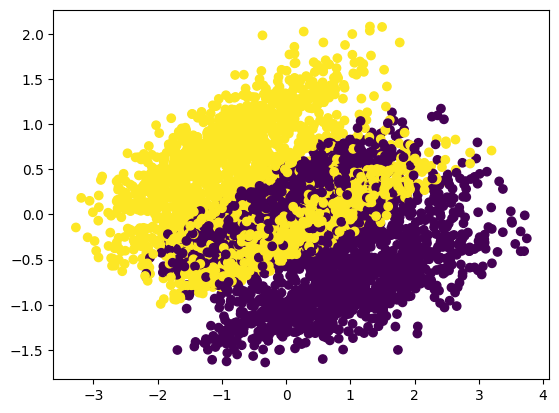

In [73]:
pd.options.display.max_colwidth=1000
def ch(text):
    return 'the' in text
y1 = np.array(df['labels'].tolist())[:, 3] #food
y2 = np.array(df['labels'].tolist())[:, 5] #country
y = np.logical_xor(y1, y2) #EXACTLY one of food and country
logica = LogisticRegression()
XP = PREm(Xembeddings).detach().numpy()
Xtrain, Xval, ytrain, yval = train_test_split(XP, y, test_size=0.2, random_state=42)
PREm = m.layers[:6]
logica.fit(Xtrain, ytrain)
print(accuracy_score(yval, logica.predict(Xval) ) )
pc = PCA(2)
X2train = pc.fit_transform(Xtrain)
plt.scatter(X2train[:, 0], X2train[:, 1], c = ytrain)
df

In [92]:
from sklearn.neighbors import KNeighborsClassifier
logica = KNeighborsClassifier(5)
Xtrain, Xval, ytrain, yval = train_test_split(Xembeddings, y, test_size=0.2, random_state=42)
logica.fit(Xtrain, ytrain)
print('xor', accuracy_score(yval, logica.predict(Xval) ) )

xor 0.695


In [93]:
Xembeddings.shape

torch.Size([7000, 384])

In [116]:
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
class Mlp(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Linear(384, 120),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
        )
        self.classifier = nn.Linear(84, 2)

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)
mlp = Mlp()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp.parameters(), lr=0.001)
traindataset = TensorDataset(Xtrain, ytrain)
valdataset = TensorDataset(Xval, torch.tensor(yval, dtype=torch.long))
trainloader = DataLoader(traindataset, batch_size=1)
for e in range(5):
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        labels = labels.long()
        optimizer.zero_grad()
        outputs = mlp(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if i % 1000 == 999:
            print(f'[{e + 1}, {i + 1:5d}] loss: {running_loss/1000:.3f}')
            running_loss = 0
    mlp.eval()
    val_preds = []
    val_true = []
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in valdataset:
            labels = labels.long()
            outputs = mlp(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=0)
            val_preds.append(preds.item())
            val_true.append(labels.item())
    acc = accuracy_score(val_true, val_preds)
    print(f"\nEpoch {e+1}")
    print(f"Val Loss: {val_loss/len(valdataset):.4f}")
    print(f"Val Acc : {acc:.4f}\n")

[1,  1000] loss: 0.682
[1,  2000] loss: 0.399
[1,  3000] loss: 0.248
[1,  4000] loss: 0.242
[1,  5000] loss: 0.200

Epoch 1
Val Loss: 0.1459
Val Acc : 0.9457

[2,  1000] loss: 0.153
[2,  2000] loss: 0.135
[2,  3000] loss: 0.108
[2,  4000] loss: 0.146
[2,  5000] loss: 0.116

Epoch 2
Val Loss: 0.1224
Val Acc : 0.9571

[3,  1000] loss: 0.085
[3,  2000] loss: 0.084
[3,  3000] loss: 0.061
[3,  4000] loss: 0.106
[3,  5000] loss: 0.071

Epoch 3
Val Loss: 0.1437
Val Acc : 0.9557

[4,  1000] loss: 0.062
[4,  2000] loss: 0.042
[4,  3000] loss: 0.049
[4,  4000] loss: 0.080
[4,  5000] loss: 0.039

Epoch 4
Val Loss: 0.1540
Val Acc : 0.9571

[5,  1000] loss: 0.046
[5,  2000] loss: 0.047
[5,  3000] loss: 0.027
[5,  4000] loss: 0.051
[5,  5000] loss: 0.032

Epoch 5
Val Loss: 0.1734
Val Acc : 0.9507



/tmp/ipykernel_57/803531586.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xs = mlp.features(torch.tensor(Xembeddings, dtype=torch.float32)).detach().numpy()


0.95


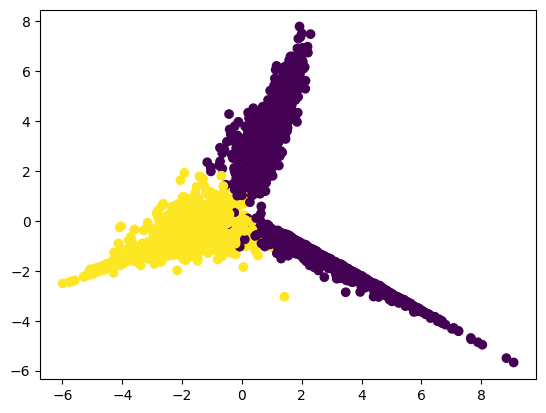

In [124]:
Xs = mlp.features(torch.tensor(Xembeddings, dtype=torch.float32)).detach().numpy()
logica = LogisticRegression()
Xtrain, Xval, ytrain, yval = train_test_split(Xs, y, test_size=0.2, random_state=42)
logica.fit(Xtrain, ytrain)
print(accuracy_score(yval, logica.predict(Xval) ) )
pc = PCA(2)
X2train = pc.fit_transform(Xtrain)
plt.scatter(X2train[:, 0], X2train[:, 1], c = ytrain)

## What you'll submit

A single google doc, documenting what you tried, what worked, what didn't, and what structure emerged in the trained model. We'll happily read about your failures if the path to them was thoughtful.